# K Means Clustering Implementation Example

In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_blobs

# Force reload the updated module
import sys
import importlib

# Clear rice_ml from all modules
for module_name in list(sys.modules.keys()):
    if 'rice_ml' in module_name:
        del sys.modules[module_name]

# Add the local source to path
sys.path.insert(0, '/Users/ccarr21/Desktop/cmor438_carr/CMOR-438-SP-2026/src')

# Import and reload the module
import rice_ml.Unsupervised_Learning.k_means_clustering
importlib.reload(rice_ml.Unsupervised_Learning.k_means_clustering)

from rice_ml.Unsupervised_Learning.k_means_clustering import KMeans

from rice_ml.processing.preprocessing import train_test_split, standardize, normalize
from rice_ml.processing.postprocessing import PostProcessor

# Set the Seaborn theme
sns.set_theme()

# Reading in the California Housing Dataset
from sklearn.datasets import fetch_california_housing
df = fetch_california_housing(as_frame=True).frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Data Exploration: California Housing Dataset

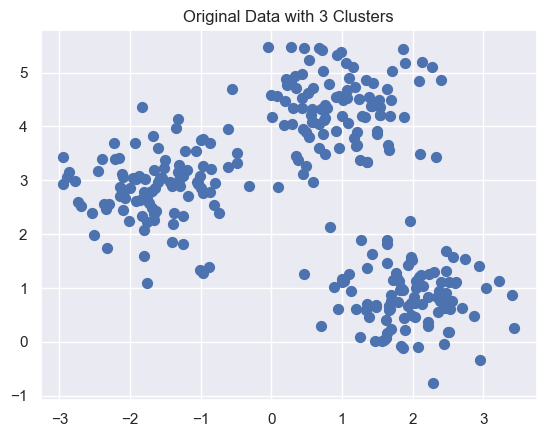

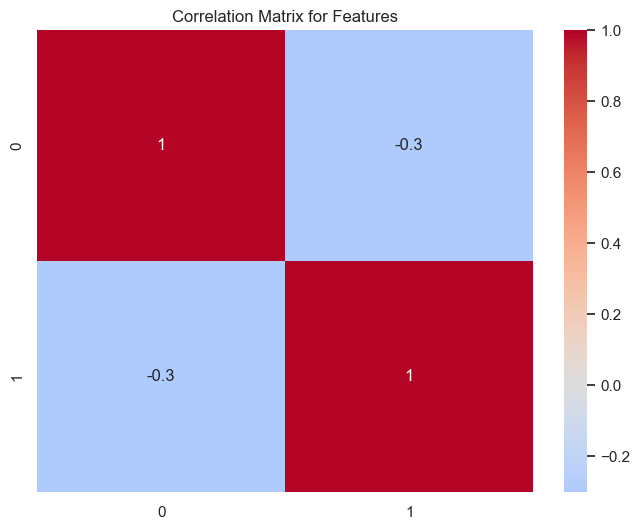

In [28]:
# Create 3 distinct clusters of data
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Original Data with 3 Clusters")
plt.show()

# Correlation Matrix for Features
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(X).corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix for Features")
plt.show()


# Preprocessing

In [29]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Verifying the shapes of the splits
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")
# Scaling the features
X_train, X_test = standardize(X_train, X_test)
# Instantiating and training the K Means Clustering Algorithm for Random and KMeans++
k_means_cluster = KMeans(n_clusters=3, random_state=42)
k_means_cluster.fit(X_train)
k_means_plus = k_means_cluster._kmeans_plus_plus_init(X_train, 3, np.random.RandomState(42))
k_means_plus.fit(X_train)

print("KMeans Clusterer trained successfully.")
print(f"KMeans Clusterer inertia: {k_means_cluster.inertia_}")
print("KMeans++ trained successfully.")
print(f"KMeans++ inertia: {k_means_plus.inertia_}")

Training features shape: (240, 2)
Testing features shape: (60, 2)
Training labels shape: (240,)
Testing labels shape: (60,)


AttributeError: 'KMeans' object has no attribute '_kmeans_plus_plus_init'

# Prediction and Evaluation

{'classification_error': 0.6, 'precision': 0.4, 'recall': 0.4, 'f1_score': 0.4, 'confusion_matrix': array([[24,  0,  0],
       [ 0,  0, 21],
       [ 0, 15,  0]])}
Accuracy: 0.4


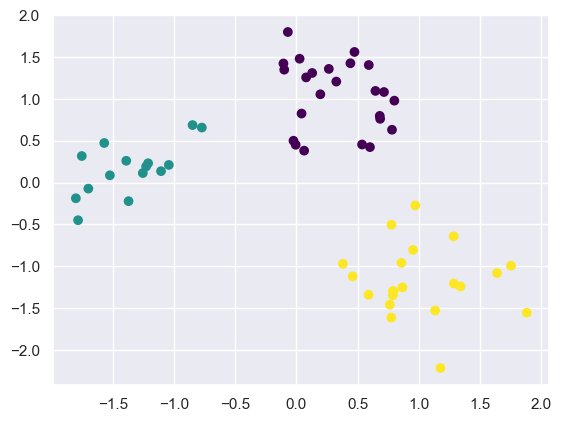

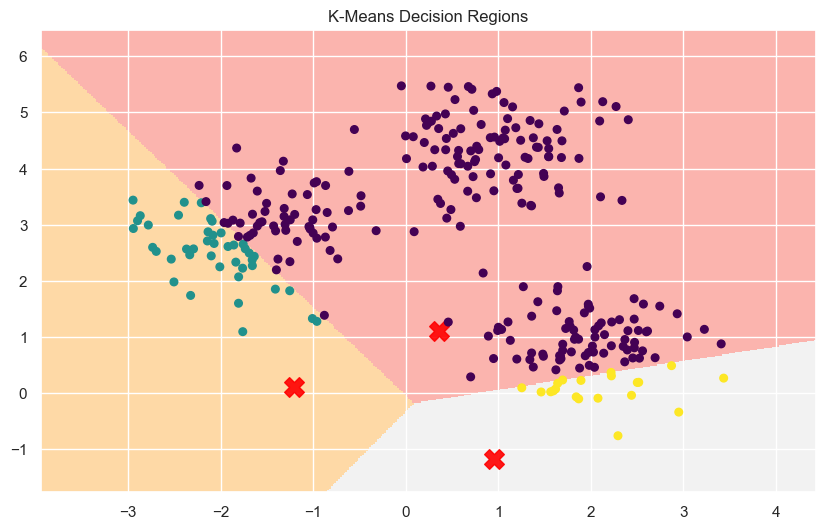

In [ ]:
processor = PostProcessor()
# Generate predictions on the test set for visualization
kmeans_pred = k_means_cluster.predict(X_test)
# Calculate metrics
metrics = processor.classification_metrics(y_test, kmeans_pred, average='weighted')
print(metrics)
# Calculate accuracy
accuracy = processor.accuracy(y_test, kmeans_pred)
print(f"Accuracy: {accuracy}")
# Calulate inertia score
#inertia = k_means_cluster.score(X_test)
#print(f"Inertia: {inertia}")

# Plot Clusters and Decision Regions
plt.scatter(X_test[:, 0], X_test[:, 1], c=kmeans_pred, cmap='viridis')
plt.show()

# Mesh for decision boundary
h = 0.02  # step size of the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Evaluate model performance by predicting labels for each point in mesh
Z = k_means_cluster.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
y_kmeans = k_means_cluster.predict(X)

# Plot Decision Regions
plt.figure(figsize=(10, 6))
plt.imshow(Z, interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap='Pastel1', origin='lower', aspect='auto') # Decision regions
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=30, cmap='viridis', zorder=2) # Data points
centers = k_means_cluster.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.9, marker='X') # Centroids
plt.title("K-Means Decision Regions")
plt.show()